<a href="https://colab.research.google.com/github/fagundespereiraGIT25/MVP_PUCRio_DataScience_Course/blob/main/MVP1_FagundesPereira_PUC_Rio_VersaoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MVP Análise de Dados e Boas Práticas

Nome: Fagundes Pereira da Silva

Matrícula: 4052025002390

Dataset: https://www.kaggle.com/harshitshankhdhar/eda-on-imdb-movies-dataset

## Análise Exploratória e Pré-processamento do Dataset IMDb Top 1000

**Tema do trabalho:** influência de gênero, popularidade e duração nas avaliações dos filmes.

Este notebook foi estruturado como relatório técnico, conforme a proposta do MVP 1 da PUC-Rio, cobrindo as etapas de **definição do problema, análise exploratória de dados (EDA)** e **pré-processamento**.

Além disso, o notebook inclui análises gráficas comparando o comportamento das variáveis **antes e depois** do tratamento de dados faltantes, nulos e desbalanceados.

## 1. Descrição do problema

Este trabalho tem como objetivo realizar uma análise exploratória e o pré-processamento do dataset `IMDb Top 1000`, buscando identificar padrões relacionados à avaliação dos filmes, sua popularidade e a possível influência de características como **gênero** e **duração**.

Trata-se de um problema de natureza **não supervisionada**, pois o foco está na compreensão da base, na formulação e verificação de hipóteses e na preparação dos dados para análises futuras. Não há, neste momento, a construção de modelos preditivos.

### Hipóteses de trabalho

1. O gênero do filme influencia sua avaliação média.  
2. O gênero influencia a popularidade, medida pelo número de votos.  
3. Existe relação entre número de votos e estabilidade das avaliações.  
4. Filmes mais longos tendem a apresentar melhores avaliações.  

### Observação metodológica

A base contém apenas filmes já selecionados entre os **Top 1000 do IMDb**. Isso influencia a distribuição das notas, uma vez que a amostra é limitada, e deve ser considerado na interpretação dos resultados. Entretanto, este recorte, apesar de limitar possíveis inferências, permite fazer uma boa discussão numa fase inicial de MVP. Fois esta a minha opção - recorte representativo de dados com Top "n".

## 2. Importação das bibliotecas

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
import requests

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

## 3. Leitura da base de dados

> **Importante:** Arquivo `imdb_top_1000.csv` foi baixado do Kaggle para o ambiente do Github, em um repositorio público da conta de fagundespereira@gmail.com.

In [79]:
url_rep_Fagundes='https://raw.githubusercontent.com/fagundespereiraGIT25/MVP_PUCRio_DataScience_Course/refs/heads/main/imdb_top_1000.csv'

df = pd.read_csv(url_rep_Fagundes)

print("Dimensão da base:", df.shape)
print(df.describe())
df.head(5)

Dimensão da base: (1000, 16)
       IMDB_Rating  Meta_score   No_of_Votes
count  1000.000000  843.000000  1.000000e+03
mean      7.949300   77.971530  2.736929e+05
std       0.275491   12.376099  3.273727e+05
min       7.600000   28.000000  2.508800e+04
25%       7.700000   70.000000  5.552625e+04
50%       7.900000   79.000000  1.385485e+05
75%       8.100000   87.000000  3.741612e+05
max       9.300000  100.000000  2.343110e+06


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


## 4. Conhecendo a estrutura dos dados

Nesta etapa, são verificados:
- quantidade de registros e colunas;
- tipos de dados;
- primeiras observações sobre possíveis inconsistências;
- existência de registros duplicados.

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [81]:
df.dtypes

,0
Poster_Link,object
Series_Title,object
Released_Year,object
Certificate,object
Runtime,object
Genre,object
IMDB_Rating,float64
Overview,object
Meta_score,float64
Director,object


In [82]:
print("Quantidade de registros duplicados:", df.duplicated().sum())

Quantidade de registros duplicados: 0


### Interpretação

A base possui variáveis numéricas e textuais. Algumas colunas que deveriam ser numéricas, como `Runtime` e `Gross`, aparecem em formato textual e precisarão ser transformadas. A verificação de duplicados é importante para evitar distorções na análise.

## 5. Descrição dos principais atributos

Os principais atributos utilizados neste estudo são:

- `Series_Title`: título do filme  
- `Released_Year`: ano de lançamento  
- `Certificate`: classificação indicativa  
- `Runtime`: duração do filme  
- `Genre`: gênero ou combinação de gêneros  
- `IMDB_Rating`: nota média no IMDb  
- `Meta_score`: nota do Metacritic  
- `No_of_Votes`: número de votos  
- `Gross`: arrecadação bruta  

## 6. Análise inicial de valores ausentes

In [83]:
missing_abs = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    'faltantes': missing_abs,
    'percentual (%)': missing_pct.round(2)
})

missing_table

,faltantes,percentual (%)
Gross,169,16.9
Meta_score,157,15.7
Certificate,101,10.1
Poster_Link,0,0.0
Runtime,0,0.0
Genre,0,0.0
Series_Title,0,0.0
Released_Year,0,0.0
Overview,0,0.0
IMDB_Rating,0,0.0


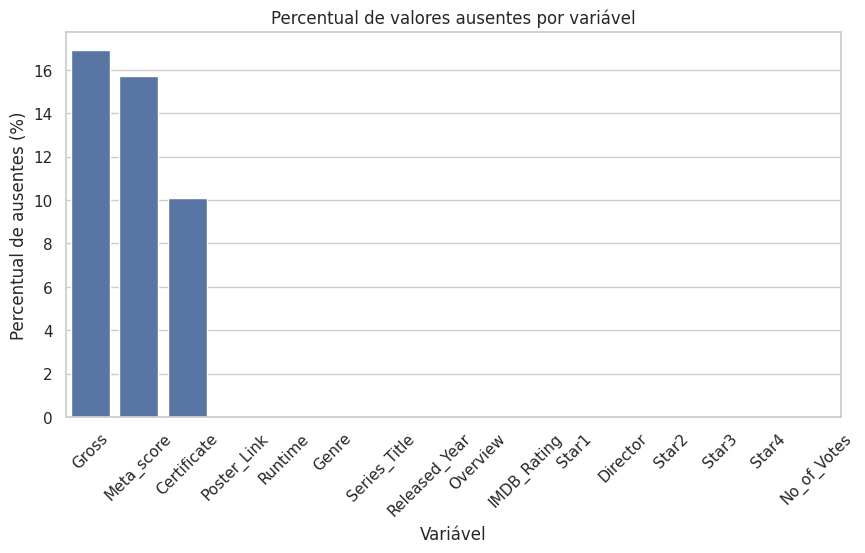

In [84]:
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_perc = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'coluna': missing_counts.index,
    'faltantes': missing_counts.values,
    'percentual': missing_perc.values
})

plt.figure(figsize=(10, 5))
sns.barplot(data=missing_df, x='coluna', y='percentual')
plt.title('Percentual de valores ausentes por variável')
plt.xlabel('Variável')
plt.ylabel('Percentual de ausentes (%)')
plt.xticks(rotation=45)
plt.show()

### Interpretação

O gráfico mostra que algumas variáveis apresentam quantidade relevante de valores ausentes, especialmente `Gross`, `Meta_score` e `Certificate`. Isso justifica tratamentos específicos para cada coluna, em vez de uma abordagem única para todos os casos.

## 7. Criação da cópia de trabalho e tratamento inicial

In [85]:
df_tratado = df.copy()

# Conversões iniciais
df_tratado['Runtime_min'] = df_tratado['Runtime'].str.extract(r'(\d+)').astype(float)

df_tratado['Gross_num'] = pd.to_numeric(
    df_tratado['Gross'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

df_tratado['Meta_score'] = pd.to_numeric(df_tratado['Meta_score'], errors='coerce')

# Flags de ausência
df_tratado['Gross_missing'] = df_tratado['Gross_num'].isnull().astype(int)
df_tratado['Meta_score_missing'] = df_tratado['Meta_score'].isnull().astype(int)

# Medianas para imputação
gross_median = df_tratado['Gross_num'].median()
meta_median = df_tratado['Meta_score'].median()

# Imputação robusta
df_tratado['Gross_num_imputed'] = df_tratado['Gross_num'].fillna(gross_median)
df_tratado['Meta_score_imputed'] = df_tratado['Meta_score'].fillna(meta_median)

# Tratamento categórico
df_tratado['Certificate'] = df_tratado['Certificate'].fillna('Unknown')

# Transformação logarítmica da popularidade
df_tratado['No_of_Votes_log'] = np.log1p(df_tratado['No_of_Votes'])

# Ano de lançamento
df_tratado['Released_Year'] = pd.to_numeric(df_tratado['Released_Year'], errors='coerce')

df_tratado.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Runtime_min,Gross_num,Gross_missing,Meta_score_missing,Gross_num_imputed,Meta_score_imputed,No_of_Votes_log
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994.0,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469",142.0,28341469.0,0,0,28341469.0,80.0,14.666990
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972.0,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411",175.0,134966411.0,0,0,134966411.0,100.0,14.298164
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008.0,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444",152.0,534858444.0,0,0,534858444.0,84.0,14.649824
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974.0,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000",202.0,57300000.0,0,0,57300000.0,90.0,13.937687
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957.0,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000",96.0,4360000.0,0,0,4360000.0,96.0,13.444224


### Justificativa metodológica

O tratamento adotado seguiu critérios distintos conforme a natureza da variável:

- `Gross`: conversão para numérico, criação de flag de ausência e imputação pela **mediana**, pois a distribuição tende a ser assimétrica e sensível a outliers.
- `Meta_score`: imputação pela **mediana**, por se tratar de variável numérica com valores faltantes.
- `Certificate`: preenchimento com a categoria explícita `"Unknown"`, por ser variável categórica.
- `No_of_Votes`: transformação logarítmica para reduzir assimetria e facilitar análises comparativas.

## 8. Comparação de nulos antes e depois do tratamento

In [86]:
antes_depois_nulos = pd.DataFrame({
    'antes': df[['Gross', 'Meta_score', 'Certificate']].isnull().sum(),
    'depois': [
        df_tratado['Gross_num_imputed'].isnull().sum(),
        df_tratado['Meta_score_imputed'].isnull().sum(),
        df_tratado['Certificate'].isnull().sum()
    ]
}, index=['Gross', 'Meta_score', 'Certificate'])

antes_depois_nulos

,antes,depois
Gross,169,0
Meta_score,157,0
Certificate,101,0


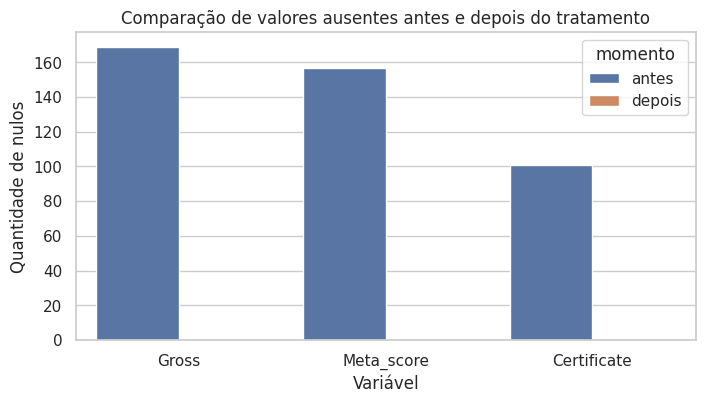

In [87]:
antes_depois_nulos_plot = antes_depois_nulos.reset_index().rename(columns={'index': 'variavel'})
antes_depois_nulos_melt = antes_depois_nulos_plot.melt(
    id_vars='variavel', var_name='momento', value_name='quantidade'
)

plt.figure(figsize=(8, 4))
sns.barplot(data=antes_depois_nulos_melt, x='variavel', y='quantidade', hue='momento')
plt.title('Comparação de valores ausentes antes e depois do tratamento')
plt.xlabel('Variável')
plt.ylabel('Quantidade de nulos')
plt.show()

### Interpretação

A comparação entre o momento anterior e posterior ao tratamento mostra que os valores ausentes das variáveis selecionadas foram tratados sem necessidade de excluir registros da base, preservando o volume de dados e aumentando a consistência das análises.

## 9. Histogramas e boxplots antes e depois do tratamento de nulos

### 9.1 Gross

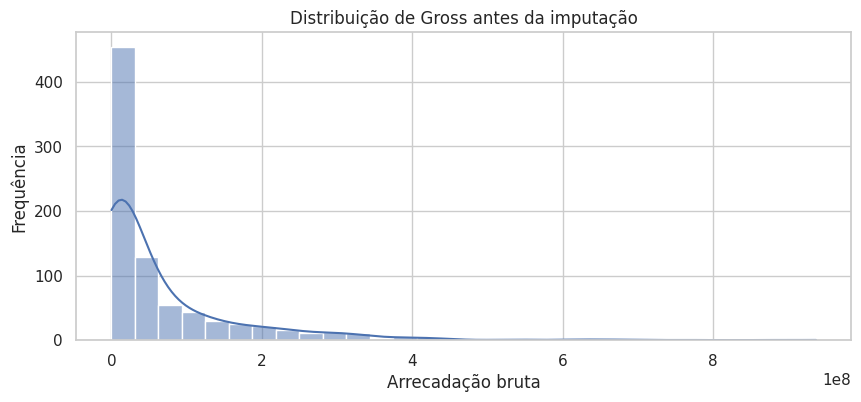

In [88]:
plt.figure(figsize=(10, 4))
sns.histplot(df_tratado['Gross_num'].dropna(), bins=30, kde=True)
plt.title('Distribuição de Gross antes da imputação')
plt.xlabel('Arrecadação bruta')
plt.ylabel('Frequência')
plt.show()

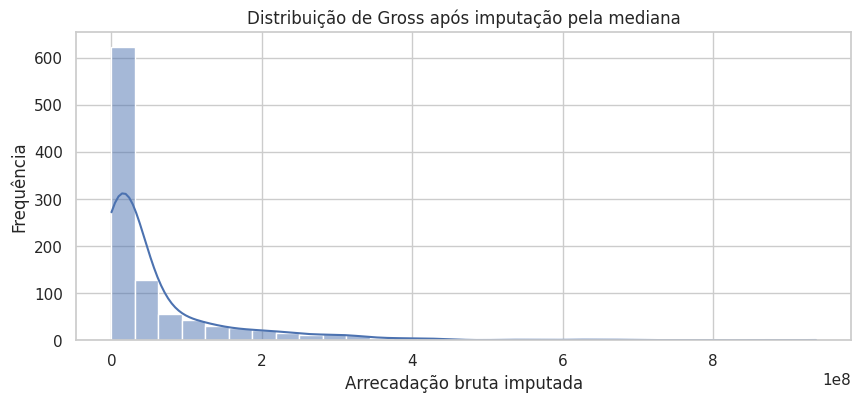

In [89]:
plt.figure(figsize=(10, 4))
sns.histplot(df_tratado['Gross_num_imputed'], bins=30, kde=True)
plt.title('Distribuição de Gross após imputação pela mediana')
plt.xlabel('Arrecadação bruta imputada')
plt.ylabel('Frequência')
plt.show()

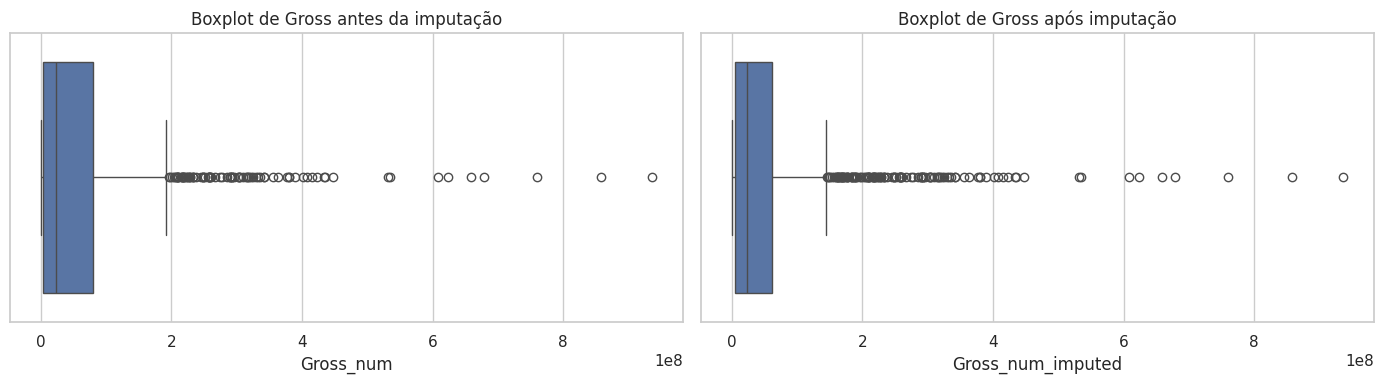

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x=df_tratado['Gross_num'].dropna(), ax=axes[0])
axes[0].set_title('Boxplot de Gross antes da imputação')

sns.boxplot(x=df_tratado['Gross_num_imputed'], ax=axes[1])
axes[1].set_title('Boxplot de Gross após imputação')

plt.tight_layout()
plt.show()

### Interpretação

A variável `Gross` apresenta forte assimetria à direita e presença de valores extremos. A imputação pela mediana preserva a forma geral da distribuição e evita deslocamentos artificiais que poderiam ocorrer caso fosse utilizada a média.

### 9.2 Meta_score

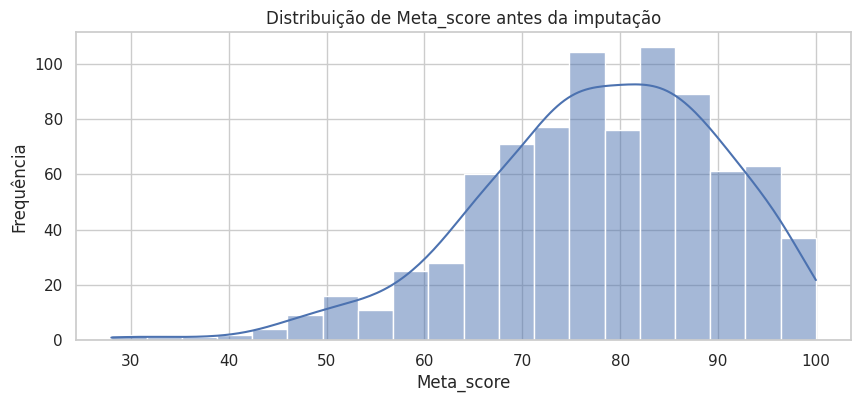

In [91]:
plt.figure(figsize=(10, 4))
sns.histplot(df_tratado['Meta_score'].dropna(), bins=20, kde=True)
plt.title('Distribuição de Meta_score antes da imputação')
plt.xlabel('Meta_score')
plt.ylabel('Frequência')
plt.show()

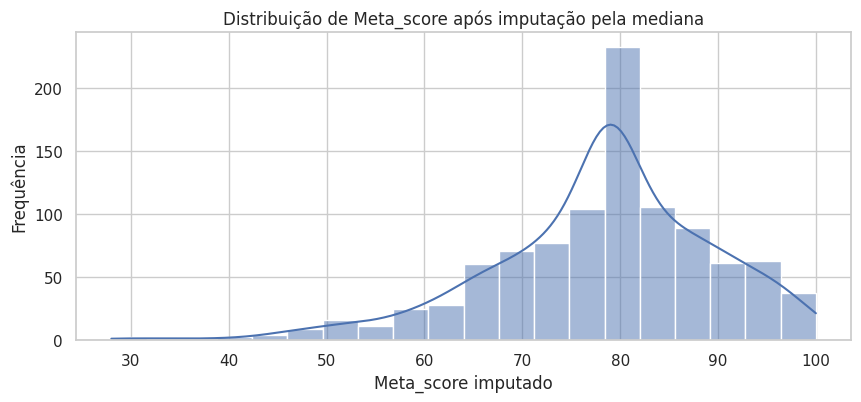

In [92]:
plt.figure(figsize=(10, 4))
sns.histplot(df_tratado['Meta_score_imputed'], bins=20, kde=True)
plt.title('Distribuição de Meta_score após imputação pela mediana')
plt.xlabel('Meta_score imputado')
plt.ylabel('Frequência')
plt.show()

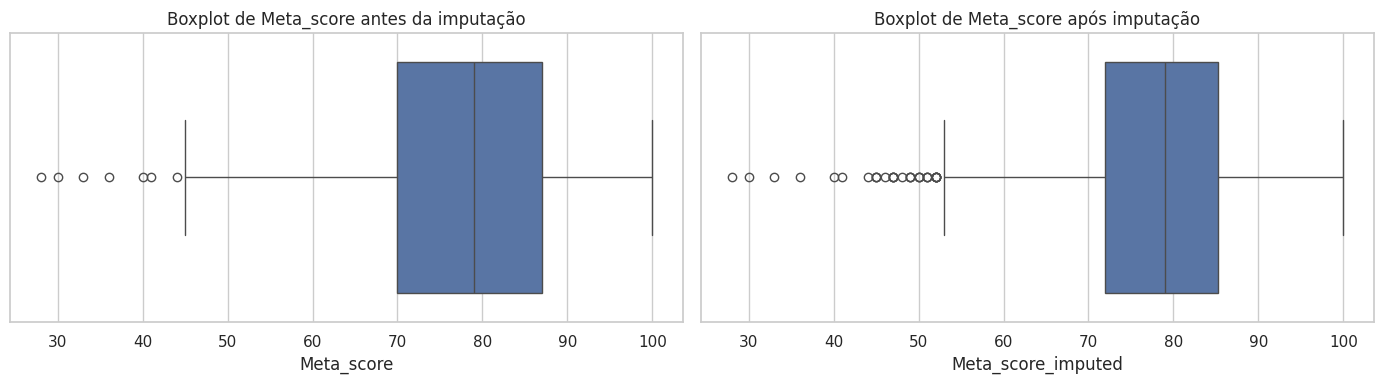

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x=df_tratado['Meta_score'].dropna(), ax=axes[0])
axes[0].set_title('Boxplot de Meta_score antes da imputação')

sns.boxplot(x=df_tratado['Meta_score_imputed'], ax=axes[1])
axes[1].set_title('Boxplot de Meta_score após imputação')

plt.tight_layout()
plt.show()

### Interpretação

A imputação do `Meta_score` pela mediana preserva a estrutura geral da variável e reduz a perda de informação. Como essa distribuição é menos extrema do que `Gross`, o efeito visual da imputação tende a ser mais sutil.

## 10. Estatísticas descritivas das principais variáveis numéricas

In [94]:
cols_num = ['IMDB_Rating', 'Meta_score_imputed', 'No_of_Votes',
            'No_of_Votes_log', 'Runtime_min', 'Gross_num_imputed']

df_tratado[cols_num].describe().T


,count,mean,std,min,25%,50%,75%,max
IMDB_Rating,1000.0,7.949300e+00,2.754912e-01,7.600000,7.700000e+00,7.900000e+00,8.100000e+00,9.300000e+00
Meta_score_imputed,1000.0,7.813300e+01,1.136823e+01,28.000000,7.200000e+01,7.900000e+01,8.525000e+01,1.000000e+02
No_of_Votes,1000.0,2.736929e+05,3.273727e+05,25088.000000,5.552625e+04,1.385485e+05,3.741612e+05,2.343110e+06
No_of_Votes_log,1000.0,1.190693e+01,1.120566e+00,10.130185,1.092463e+01,1.183898e+01,1.283244e+01,1.466699e+01
Runtime_min,1000.0,1.228910e+02,2.809367e+01,45.000000,1.030000e+02,1.190000e+02,1.370000e+02,3.210000e+02
Gross_num_imputed,1000.0,6.051360e+07,1.014192e+08,1305.000000,5.012919e+06,2.353089e+07,6.153989e+07,9.366622e+08


In [95]:
df_tratado[cols_num].corr()

,IMDB_Rating,Meta_score_imputed,No_of_Votes,No_of_Votes_log,Runtime_min,Gross_num_imputed
IMDB_Rating,1.000000,0.258650,0.494979,0.325238,0.243096,0.085518
Meta_score_imputed,0.258650,1.000000,-0.026940,-0.066936,-0.026361,-0.051889
No_of_Votes,0.494979,-0.026940,1.000000,0.863331,0.173264,0.588428
No_of_Votes_log,0.325238,-0.066936,0.863331,1.000000,0.138776,0.553663
Runtime_min,0.243096,-0.026361,0.173264,0.138776,1.000000,0.138353
Gross_num_imputed,0.085518,-0.051889,0.588428,0.553663,0.138353,1.000000


### Interpretação

As estatísticas descritivas mostram que:
- as notas IMDb possuem baixa dispersão relativa;
- o número de votos apresenta forte variabilidade;
- a transformação logarítmica melhora a interpretação da popularidade;
- duração e metascore são mais estáveis do ponto de vista distributivo.

## 11. Distribuição das notas IMDb

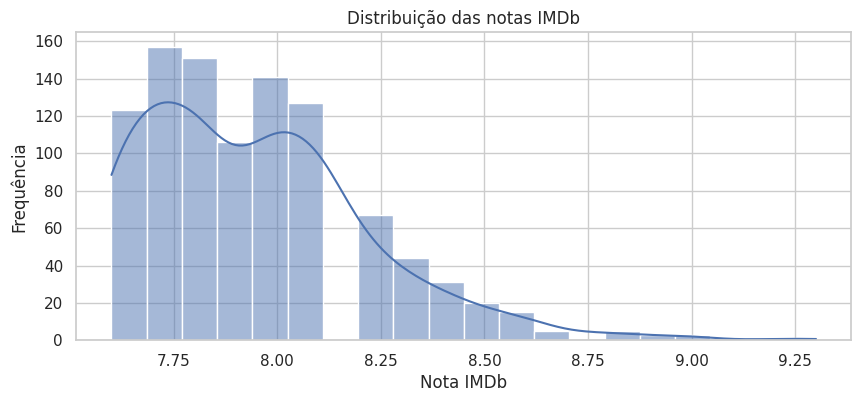

In [96]:
plt.figure(figsize=(10, 4))
sns.histplot(df_tratado['IMDB_Rating'], bins=20, kde=True)
plt.title('Distribuição das notas IMDb')
plt.xlabel('Nota IMDb')
plt.ylabel('Frequência')
plt.show()

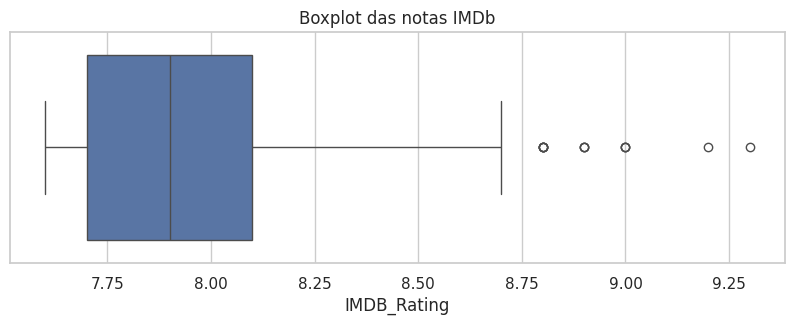

In [97]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_tratado['IMDB_Rating'])
plt.title('Boxplot das notas IMDb')
plt.show()

### Interpretação

As notas IMDb concentram-se em valores elevados, o que é esperado em uma base composta pelos filmes do Top 1000. Essa característica precisa ser considerada ao interpretar a influência de outras variáveis sobre a avaliação.

## 12. Análise do desbalanceamento da popularidade (`No_of_Votes`)

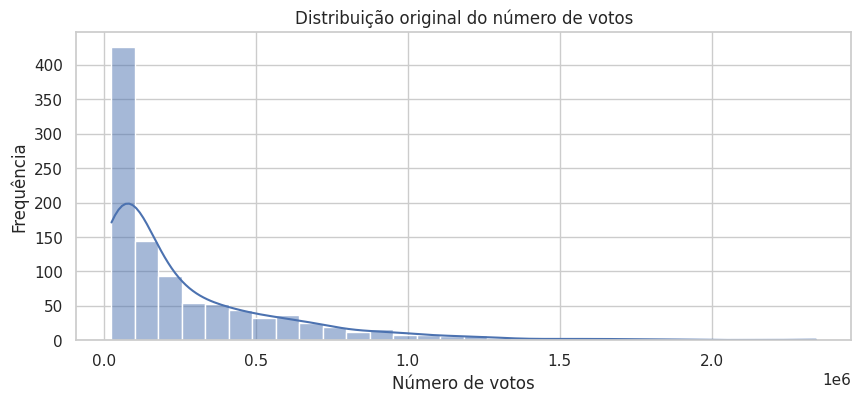

In [98]:
plt.figure(figsize=(10, 4))
sns.histplot(df_tratado['No_of_Votes'], bins=30, kde=True)
plt.title('Distribuição original do número de votos')
plt.xlabel('Número de votos')
plt.ylabel('Frequência')
plt.show()

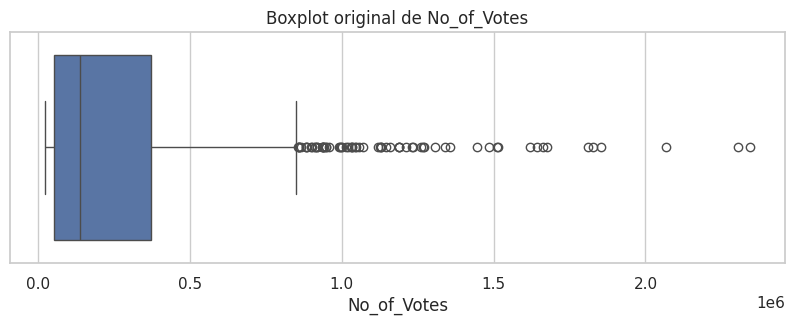

In [99]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_tratado['No_of_Votes'])
plt.title('Boxplot original de No_of_Votes')
plt.show()

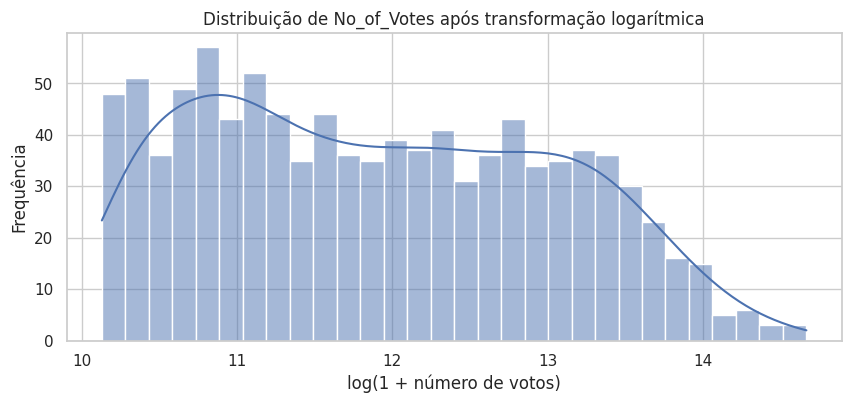

In [100]:
plt.figure(figsize=(10, 4))
sns.histplot(df_tratado['No_of_Votes_log'], bins=30, kde=True)
plt.title('Distribuição de No_of_Votes após transformação logarítmica')
plt.xlabel('log(1 + número de votos)')
plt.ylabel('Frequência')
plt.show()

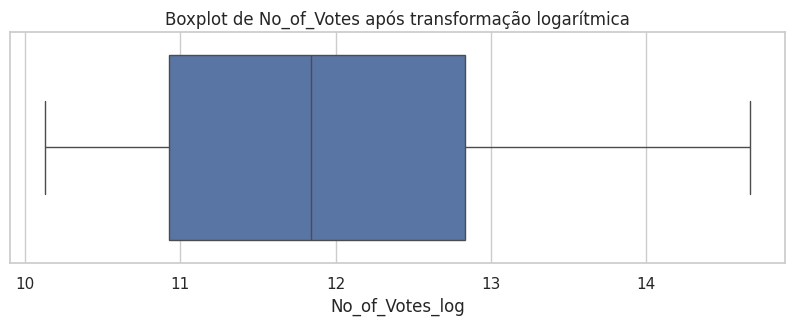

In [101]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_tratado['No_of_Votes_log'])
plt.title('Boxplot de No_of_Votes após transformação logarítmica')
plt.show()

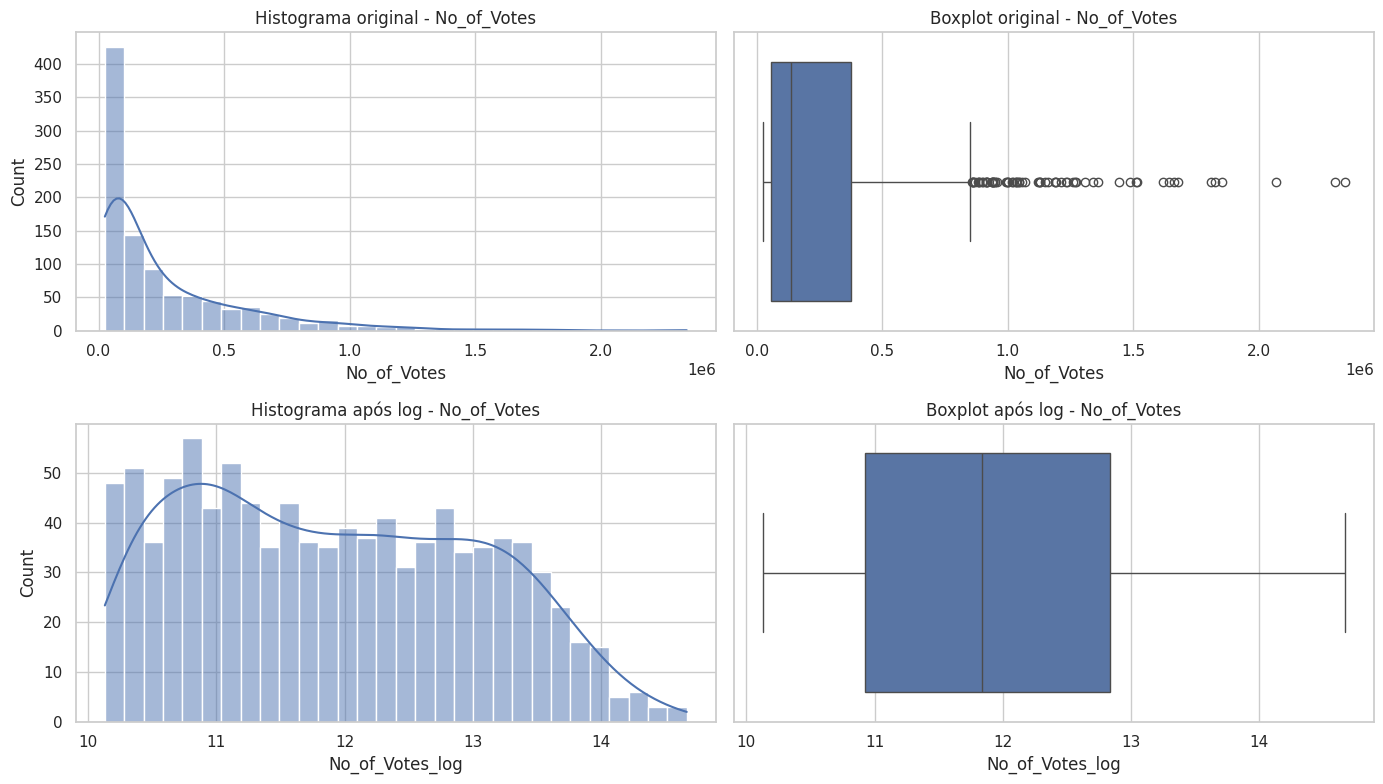

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df_tratado['No_of_Votes'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Histograma original - No_of_Votes')

sns.boxplot(x=df_tratado['No_of_Votes'], ax=axes[0, 1])
axes[0, 1].set_title('Boxplot original - No_of_Votes')

sns.histplot(df_tratado['No_of_Votes_log'], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Histograma após log - No_of_Votes')

sns.boxplot(x=df_tratado['No_of_Votes_log'], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot após log - No_of_Votes')

plt.tight_layout()
plt.show()

### Interpretação

O número de votos apresenta forte desbalanceamento, com poucos filmes muito populares e muitos filmes com menos votos. A transformação logarítmica reduz a assimetria, tornando a distribuição mais compacta e facilitando a comparação entre observações.

## 13. Análise da duração dos filmes

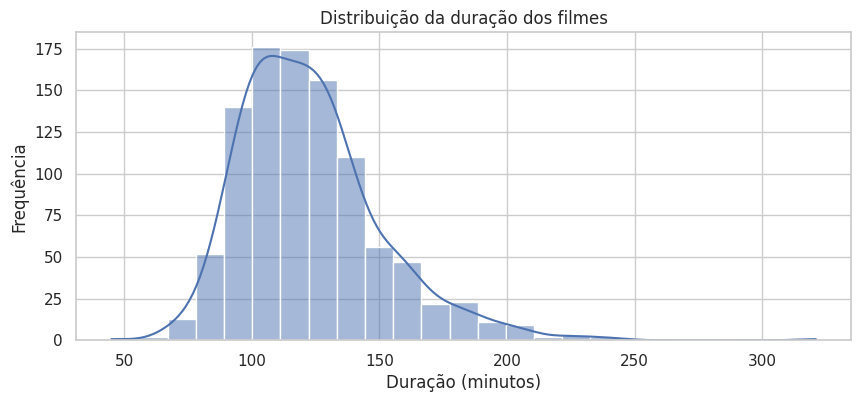

In [103]:
plt.figure(figsize=(10, 4))
sns.histplot(df_tratado['Runtime_min'], bins=25, kde=True)
plt.title('Distribuição da duração dos filmes')
plt.xlabel('Duração (minutos)')
plt.ylabel('Frequência')
plt.show()

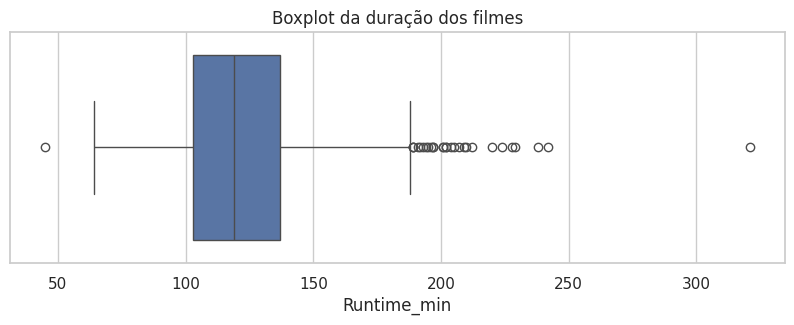

In [104]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_tratado['Runtime_min'])
plt.title('Boxplot da duração dos filmes')
plt.show()

### Interpretação

A duração dos filmes apresenta distribuição mais estável que o número de votos, com predominância de longas-metragens em faixas intermediárias. Há alguns filmes muito longos, mas sem a mesma intensidade de extremos observada em `No_of_Votes`.

## 14. Preparação da variável gênero para análise

Como um filme pode possuir mais de um gênero, é necessário separar os gêneros em linhas individuais para permitir análises mais adequadas.

In [105]:
df_gen = df_tratado.copy()
df_gen['Genre'] = df_gen['Genre'].str.split(',')
df_gen = df_gen.explode('Genre')
df_gen['Genre'] = df_gen['Genre'].str.strip()

df_gen[['Series_Title', 'Genre']].head(10)

,Series_Title,Genre
0,The Shawshank Redemption,Drama
1,The Godfather,Crime
1,The Godfather,Drama
2,The Dark Knight,Action
2,The Dark Knight,Crime
2,The Dark Knight,Drama
3,The Godfather: Part II,Crime
3,The Godfather: Part II,Drama
4,12 Angry Men,Crime
4,12 Angry Men,Drama


In [106]:
genre_counts = df_gen['Genre'].value_counts()
genre_counts

,count
Genre,
Drama,724
Comedy,233
Crime,209
Adventure,196
Action,189
Thriller,137
Romance,125
Biography,109
Mystery,99


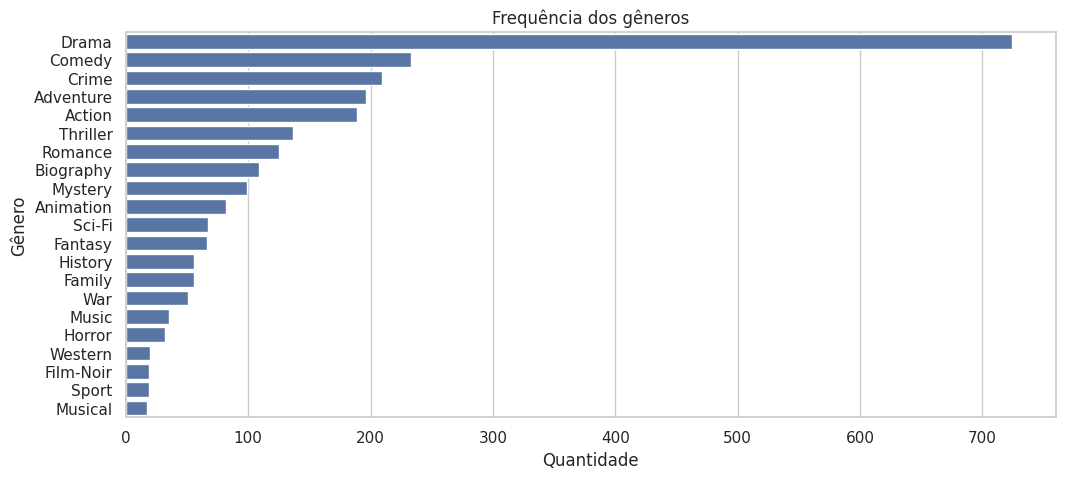

In [107]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df_gen, y='Genre', order=df_gen['Genre'].value_counts().index)
plt.title('Frequência dos gêneros')
plt.xlabel('Quantidade')
plt.ylabel('Gênero')
plt.show()

### Interpretação

A distribuição dos gêneros é claramente desbalanceada, com algumas categorias muito frequentes e outras raras. Isso pode prejudicar comparações entre grupos, pois gêneros pouco representados tendem a gerar médias menos estáveis.

## 15. Agrupamento de gêneros raros para reduzir desbalanceamento

In [108]:
limite_genero = 20
generos_frequentes = genre_counts[genre_counts >= limite_genero].index

df_gen['Genre_grouped'] = df_gen['Genre'].where(
    df_gen['Genre'].isin(generos_frequentes),
    'Outros'
)

df_gen['Genre_grouped'].value_counts()

,count
Genre_grouped,
Drama,724
Comedy,233
Crime,209
Adventure,196
Action,189
Thriller,137
Romance,125
Biography,109
Mystery,99


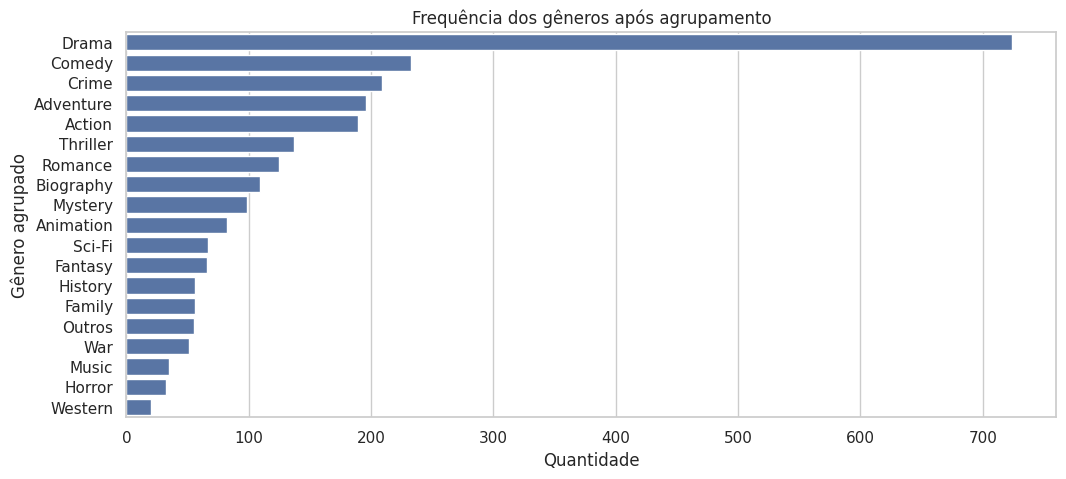

In [109]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df_gen, y='Genre_grouped', order=df_gen['Genre_grouped'].value_counts().index)
plt.title('Frequência dos gêneros após agrupamento')
plt.xlabel('Quantidade')
plt.ylabel('Gênero agrupado')
plt.show()

### Interpretação

O agrupamento de gêneros raros em `"Outros"` reduz o problema de baixa representatividade e melhora a robustez das comparações entre grupos.

## 16. Hipótese 1 — O gênero influencia a avaliação média

In [110]:
rating_by_genre = (
    df_gen.groupby('Genre_grouped')['IMDB_Rating']
    .agg(['count', 'mean', 'median', 'std'])
    .sort_values('mean', ascending=False)
)

rating_by_genre

,count,mean,median,std
Genre_grouped,,,,
War,51,8.013725,8.00,0.278582
Western,20,8.000000,7.95,0.324443
Sci-Fi,67,7.977612,7.90,0.286473
Mystery,99,7.967677,8.00,0.272864
Drama,724,7.959392,7.90,0.280057
Outros,55,7.954545,8.00,0.206217
Crime,209,7.954545,7.90,0.307582
History,56,7.953571,7.95,0.256525
Adventure,196,7.952041,7.90,0.282200


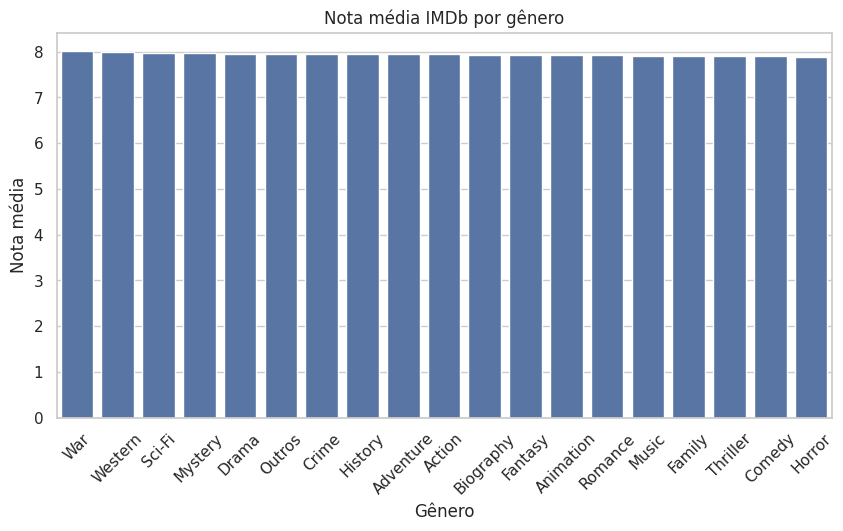

In [111]:
plt.figure(figsize=(10, 5))
sns.barplot(x=rating_by_genre.index, y=rating_by_genre['mean'])
plt.title('Nota média IMDb por gênero')
plt.xlabel('Gênero')
plt.ylabel('Nota média')
plt.xticks(rotation=45)
plt.show()

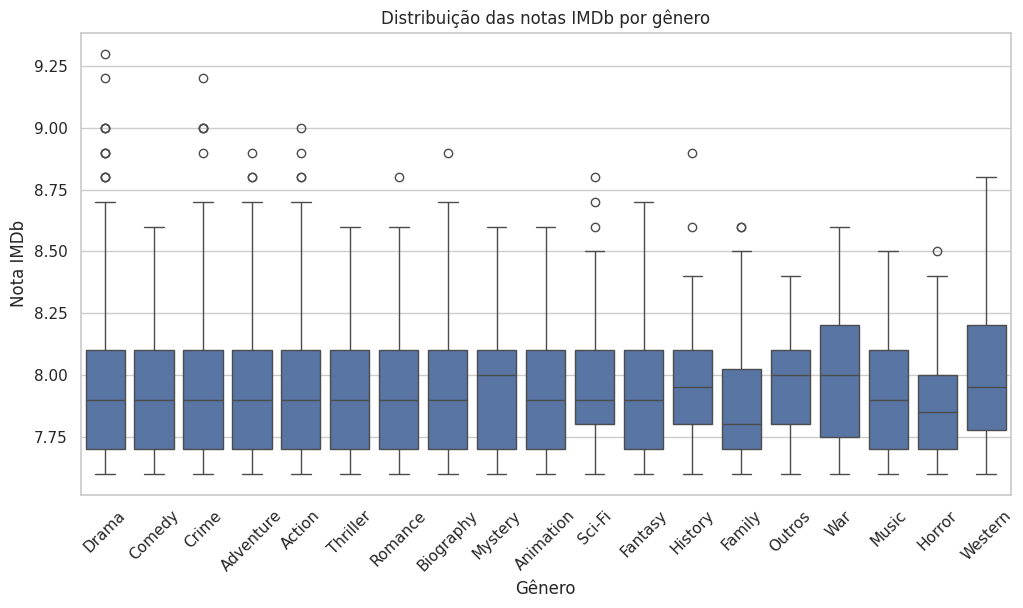

In [112]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_gen, x='Genre_grouped', y='IMDB_Rating',
            order=df_gen['Genre_grouped'].value_counts().index)
plt.title('Distribuição das notas IMDb por gênero')
plt.xlabel('Gênero')
plt.ylabel('Nota IMDb')
plt.xticks(rotation=45)
plt.show()

### Interpretação

A comparação das médias e distribuições sugere que alguns gêneros apresentam avaliações sistematicamente mais altas do que outros. O boxplot complementa a análise ao mostrar não apenas a média, mas também a dispersão das notas em cada grupo.

## 17. Hipótese 2 — O gênero influencia a popularidade

In [113]:
votes_by_genre = (
    df_gen.groupby('Genre_grouped')['No_of_Votes']
    .agg(['count', 'mean', 'median', 'std'])
    .sort_values('mean', ascending=False)
)

votes_by_genre

,count,mean,median,std
Genre_grouped,,,,
Sci-Fi,67,556242.477612,556608.0,414824.549498
Adventure,196,424952.954082,302404.5,389572.463164
Action,189,404172.412698,253228.0,420323.689014
Fantasy,66,347097.060606,254132.0,316094.286115
Thriller,137,300050.744526,186734.0,290168.708086
Mystery,99,293463.363636,174125.0,291811.779357
Crime,209,281322.124402,129231.0,352181.250317
Animation,82,268032.073171,169246.0,262173.231571
Biography,109,251898.550459,159886.0,255562.889193


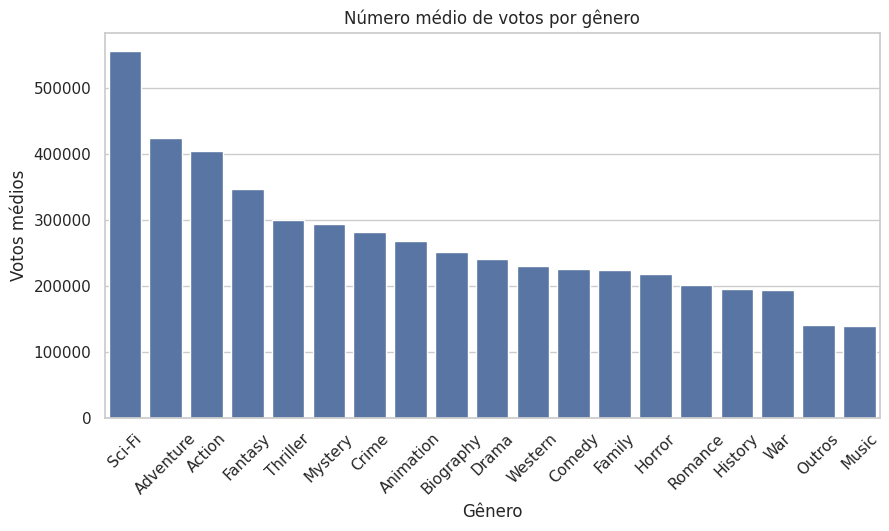

In [114]:
plt.figure(figsize=(10, 5))
sns.barplot(x=votes_by_genre.index, y=votes_by_genre['mean'])
plt.title('Número médio de votos por gênero')
plt.xlabel('Gênero')
plt.ylabel('Votos médios')
plt.xticks(rotation=45)
plt.show()

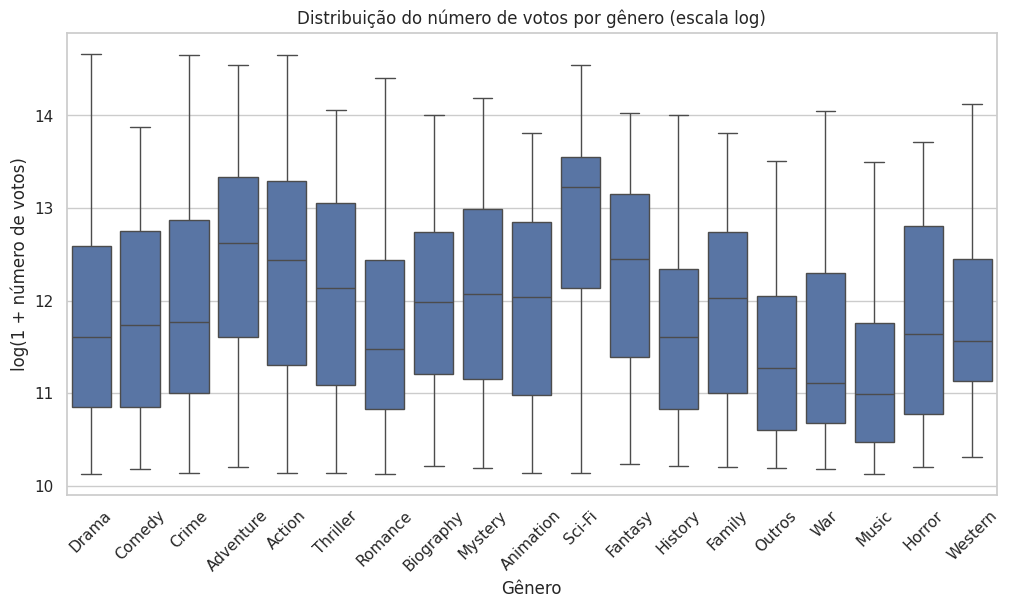

In [115]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_gen, x='Genre_grouped', y='No_of_Votes_log',
            order=df_gen['Genre_grouped'].value_counts().index)
plt.title('Distribuição do número de votos por gênero (escala log)')
plt.xlabel('Gênero')
plt.ylabel('log(1 + número de votos)')
plt.xticks(rotation=45)
plt.show()

### Interpretação

A análise indica que o gênero também pode influenciar a popularidade. O uso da variável em escala logarítmica é importante para evitar que poucos filmes extremamente populares dominem completamente a visualização.

## 18. Hipótese 3 — Existe relação entre número de votos e estabilidade das avaliações

In [116]:
df_tratado['votes_bin'] = pd.qcut(
    df_tratado['No_of_Votes'],
    q=4,
    labels=['Baixa popularidade', 'Média-baixa', 'Média-alta', 'Alta popularidade']
)

stability_by_votes = (
    df_tratado.groupby('votes_bin')['IMDB_Rating']
    .agg(['count', 'mean', 'std', 'min', 'max'])
)

stability_by_votes

/tmp/ipykernel_3166/2118568767.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tratado.groupby('votes_bin')['IMDB_Rating']


,count,mean,std,min,max
votes_bin,,,,,
Baixa popularidade,250,7.9064,0.207391,7.6,8.6
Média-baixa,250,7.8832,0.198078,7.6,8.4
Média-alta,250,7.9016,0.255379,7.6,8.6
Alta popularidade,250,8.1060,0.351937,7.6,9.3


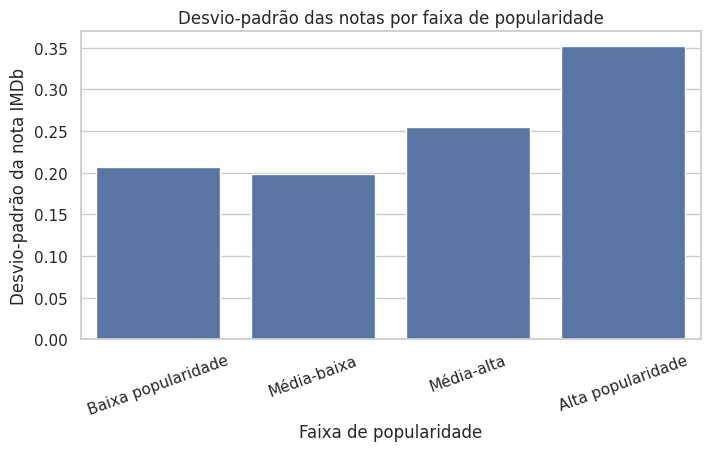

In [117]:
plt.figure(figsize=(8, 4))
sns.barplot(x=stability_by_votes.index, y=stability_by_votes['std'])
plt.title('Desvio-padrão das notas por faixa de popularidade')
plt.xlabel('Faixa de popularidade')
plt.ylabel('Desvio-padrão da nota IMDb')
plt.xticks(rotation=20)
plt.show()

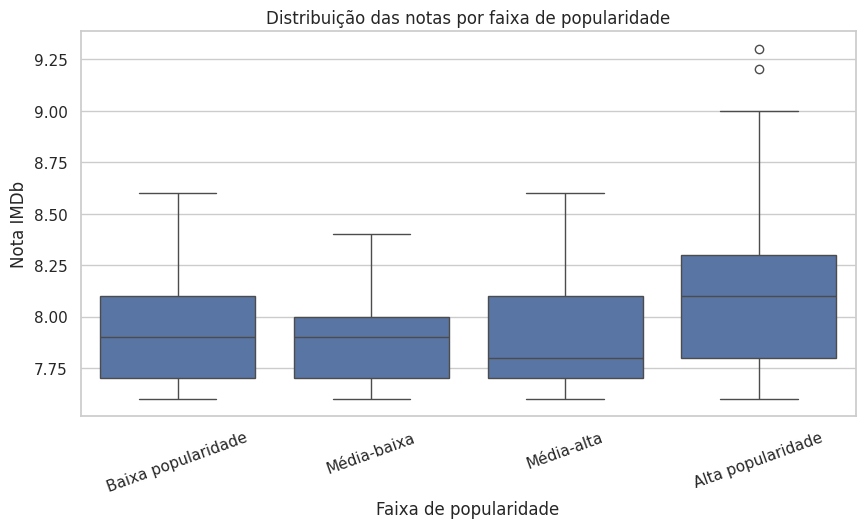

In [118]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_tratado, x='votes_bin', y='IMDB_Rating')
plt.title('Distribuição das notas por faixa de popularidade')
plt.xlabel('Faixa de popularidade')
plt.ylabel('Nota IMDb')
plt.xticks(rotation=20)
plt.show()

### Interpretação

A estabilidade das avaliações foi analisada a partir da dispersão das notas em grupos de popularidade. Caso as faixas mais populares apresentem menor desvio-padrão, isso sugere maior consenso entre os usuários.

## 19. Hipótese 4 — Filmes mais longos tendem a apresentar melhores avaliações

In [119]:
corr_runtime_rating = df_tratado[['Runtime_min', 'IMDB_Rating']].corr().iloc[0, 1]
print('Correlação entre duração e nota IMDb:', round(corr_runtime_rating, 4))

Correlação entre duração e nota IMDb: 0.2431


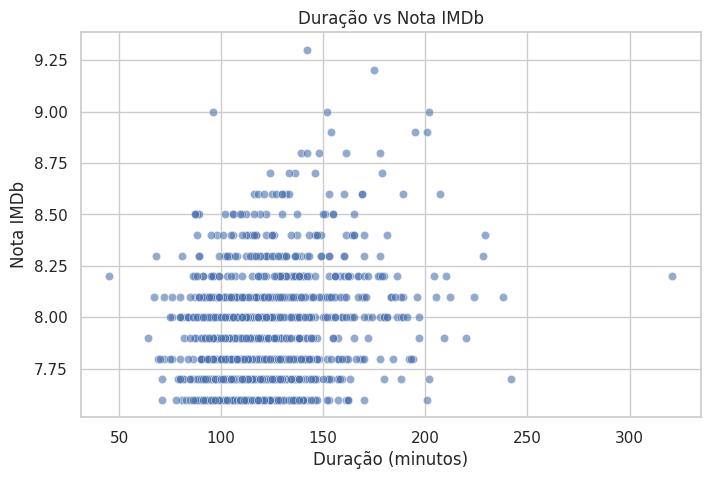

In [120]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_tratado, x='Runtime_min', y='IMDB_Rating', alpha=0.6)
plt.title('Duração vs Nota IMDb')
plt.xlabel('Duração (minutos)')
plt.ylabel('Nota IMDb')
plt.show()

In [121]:
df_tratado['runtime_bin'] = pd.cut(
    df_tratado['Runtime_min'],
    bins=[0, 90, 120, 150, 300],
    labels=['Curtos', 'Médios', 'Longos', 'Muito longos']
)

runtime_group = (
    df_tratado.groupby('runtime_bin')['IMDB_Rating']
    .agg(['count', 'mean', 'median', 'std'])
)

runtime_group

/tmp/ipykernel_3166/3188476128.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tratado.groupby('runtime_bin')['IMDB_Rating']


,count,mean,median,std
runtime_bin,,,,
Curtos,78,7.917949,7.9,0.249542
Médios,445,7.892360,7.9,0.234011
Longos,330,7.967576,7.9,0.283825
Muito longos,146,8.096575,8.1,0.325346


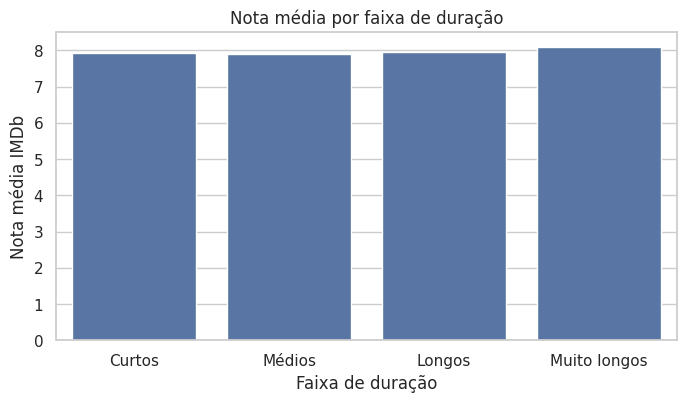

In [122]:
plt.figure(figsize=(8, 4))
sns.barplot(x=runtime_group.index, y=runtime_group['mean'])
plt.title('Nota média por faixa de duração')
plt.xlabel('Faixa de duração')
plt.ylabel('Nota média IMDb')
plt.show()

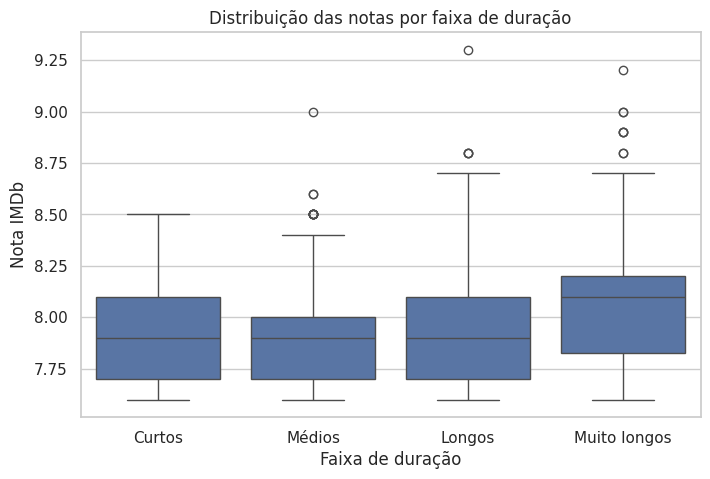

In [123]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_tratado, x='runtime_bin', y='IMDB_Rating')
plt.title('Distribuição das notas por faixa de duração')
plt.xlabel('Faixa de duração')
plt.ylabel('Nota IMDb')
plt.show()

### Interpretação

A relação entre duração e avaliação foi analisada por correlação, dispersão e comparação entre faixas de duração. Caso a relação observada seja fraca ou inconsistente, a hipótese de que filmes mais longos são melhor avaliados tende a ser apenas parcialmente sustentada ou refutada.

## 20. Consolidação do pré-processamento

As principais operações de pré-processamento realizadas foram:

- verificação de duplicados;
- análise e tratamento de valores ausentes;
- conversão de variáveis textuais para numéricas;
- criação de flags de ausência;
- imputação por mediana em variáveis numéricas com nulos;
- preenchimento explícito de categoria ausente em variável categórica;
- transformação logarítmica de variável desbalanceada;
- separação e agrupamento de gêneros.

## 21. Conclusão

A análise exploratória mostrou que a base apresenta características importantes do ponto de vista metodológico, especialmente:

- presença de dados ausentes em variáveis específicas;
- forte assimetria e desbalanceamento em `No_of_Votes`;
- concentração das notas IMDb em valores altos;
- distribuição não uniforme entre os gêneros.

O tratamento adotado buscou preservar o máximo de informação possível, sem recorrer à exclusão desnecessária de registros. A imputação por mediana, a criação de flags de ausência, a transformação logarítmica e o agrupamento de gêneros raros tornaram a base mais adequada para análise.

Com base nas visualizações e estatísticas produzidas, o notebook permite avaliar as hipóteses propostas de forma estruturada e fundamentada, em conformidade com a proposta do MVP 1.